## 第一題

## 第二題

In [83]:
import time 
from functools import reduce
from collections import Counter
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

In [84]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [85]:
# 圖形設定中文
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = './SourceHanSansTW-Regular.otf'  # Your font path goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus']=False #使負號能夠顯示
plt.rcParams['font.sans-serif'] = prop.get_name()

In [86]:
udn = pd.read_csv("raw_data/ct.csv")  # 匯資料
udn.head(3)

,artTitle,artContent,artCatagory
0,NBA》年薪1800萬美元仍遭棄用 佛尼耶：尼克不會留我,剛被熱火淘汰出局的尼克，雖在2021年跟法國籍射手佛尼耶簽下4年7300萬美元合約，本季年薪...,體育
1,「魔獸」要離台了！ 雲豹曝霍華德這時間搭機返回美國,前NBA球星、現台灣T1聯盟桃園雲豹隊中鋒「魔獸」霍華德（Dwight Howard）在台打...,體育
2,桃園市民卡免費看球！ 張善政邀進場「支猿收贏」,桃園市長張善政今下午贈送「好事花生」禮盒及景福宮平安符給桃園璞園領航猿，恭賀在地球隊順利闖進...,體育


In [88]:
# 移除網址格式
# 只留下中文字
udn["artContent"] = udn["artContent"].str.replace("(http|https)://.*", "", regex=True)
udn["artTitle"] = udn["artTitle"].str.replace("(http|https)://.*", "", regex=True)
udn["artContent"] = udn["artContent"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
udn["artTitle"] = udn["artTitle"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
udn['content'] = udn['artContent']


udn = udn.loc[:,["content", "artCatagory"]]  # 文章內容 文章連結
udn.head(3)

,content,artCatagory
0,剛被熱火淘汰出局的尼克雖在年跟法國籍射手佛尼耶簽下年萬美元合約本季年薪萬美元更居全隊第高尼克...,體育
1,前球星現台灣聯盟桃園雲豹隊中鋒魔獸霍華德在台打球時曾吹起一股魔獸旋風雖然他無緣季後賽但仍續留...,體育
2,桃園市長張善政今下午贈送好事花生禮盒及景福宮平安符給桃園璞園領航猿恭賀在地球隊順利闖進季後賽...,體育


In [91]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

udn["words"] = udn["content"].apply(getToken)
udn.head()

Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\final\dict\dict.txt ...
2023-06-03 17:09:56,651 : DEBUG : Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\final\dict\dict.txt ...
Dumping model to file cache C:\Users\user\AppData\Local\Temp\jieba.u698d4bc38583ff40bbcef8930484f85a.cache
2023-06-03 17:09:57,430 : DEBUG : Dumping model to file cache C:\Users\user\AppData\Local\Temp\jieba.u698d4bc38583ff40bbcef8930484f85a.cache
Loading model cost 0.836 seconds.
2023-06-03 17:09:57,487 : DEBUG : Loading model cost 0.836 seconds.
Prefix dict has been built successfully.
2023-06-03 17:09:57,487 : DEBUG : Prefix dict has been built successfully.


,content,artCatagory,words
0,剛被熱火淘汰出局的尼克雖在年跟法國籍射手佛尼耶簽下年萬美元合約本季年薪萬美元更居全隊第高尼克...,體育,"[剛被, 熱火, 淘汰, 出局, 尼克, 法國籍, 射手, 佛尼, 簽下, 美元, 合約, ..."
1,前球星現台灣聯盟桃園雲豹隊中鋒魔獸霍華德在台打球時曾吹起一股魔獸旋風雖然他無緣季後賽但仍續留...,體育,"[球星, 台灣, 聯盟, 桃園, 雲豹, 中鋒, 魔獸, 霍華德, 打球, 吹起, 一股, ..."
2,桃園市長張善政今下午贈送好事花生禮盒及景福宮平安符給桃園璞園領航猿恭賀在地球隊順利闖進季後賽...,體育,"[桃園, 市長, 張善政, 今下午, 贈送, 好事, 花生, 禮盒, 景福宮, 平安, 符給..."
3,緯來體育台月底推出號稱史上最狂贈獎送球迷前進美國看總冠軍賽一人中獎兩人同行機票住宿全都包活動...,體育,"[緯來, 體育台, 月底, 推出, 號稱, 史上, 最狂, 贈獎, 球迷, 前進, 美國, ..."
4,太陽指揮官保羅昨在第節剩下分秒時因衝搶籃板球拉傷腹股溝提前退場鳳凰城軍心大亂全場投籃命中率僅...,體育,"[太陽, 指揮官, 保羅, 昨在, 第節, 剩下, 分秒, 因衝, 籃板球, 拉傷, 腹股溝..."


In [92]:
docs = udn['words'].to_list()
docs[0]

['剛被',
 '熱火',
 '淘汰',
 '出局',
 '尼克',
 '法國籍',
 '射手',
 '佛尼',
 '簽下',
 '美元',
 '合約',
 '本季',
 '年薪',
 '美元',
 '更居',
 '全隊',
 '第高',
 '尼克',
 '總教練',
 '席波迪',
 '選擇',
 '本季',
 '棄用',
 '佛尼',
 '了場',
 '平均',
 '只拿分',
 '無奈',
 '表示',
 '尼克',
 '不可能',
 '留下',
 '吃驚',
 '本季',
 '以前',
 '結束',
 '時間',
 '消化',
 '感覺',
 '告訴',
 '耐心',
 '看看',
 '球隊',
 '狀況',
 '交易',
 '佛尼',
 '耶說',
 '這很讓',
 '沮喪',
 '熱愛',
 '比賽',
 '家生',
 '悶氣',
 '我家裡',
 '兩個',
 '孩子',
 '活成',
 '事實',
 '佛尼',
 '上季',
 '剛到',
 '尼克',
 '備受',
 '重用',
 '例行賽',
 '場場',
 '先發',
 '平均',
 '更拿分',
 '籃板',
 '助攻',
 '席波迪',
 '本季',
 '突然',
 '大幅',
 '採用',
 '萊姆',
 '斯奎',
 '克利',
 '新秀',
 '佛尼',
 '飆風',
 '玫瑰',
 '羅斯',
 '棄用',
 '登錄',
 '上場',
 '窘境',
 '今年',
 '東區',
 '準決賽',
 '尼克',
 '三分',
 '命中率',
 '低迷',
 '成席',
 '波迪',
 '依舊',
 '考慮',
 '啟用',
 '上季',
 '三分',
 '命中率',
 '佛尼',
 '後場',
 '上場',
 '時間',
 '交給',
 '布朗',
 '哈特',
 '萊姆',
 '打好',
 '打滿',
 '佛尼',
 '耶說',
 '感覺',
 '幫上',
 '這一',
 '整季']

In [93]:
dictionary = Dictionary(docs)
# Filter out words that occur less than 20 documents, or more than 99% of the documents.
dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

2023-06-03 17:10:32,415 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2023-06-03 17:10:32,610 : INFO : built Dictionary<21560 unique tokens: ['三分', '上場', '上季', '不可能', '了場']...> from 797 documents (total 131223 corpus positions)
2023-06-03 17:10:32,610 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<21560 unique tokens: ['三分', '上場', '上季', '不可能', '了場']...> from 797 documents (total 131223 corpus positions)", 'datetime': '2023-06-03T17:10:32.610012', 'gensim': '4.3.1', 'python': '3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22621-SP0', 'event': 'created'}
2023-06-03 17:10:32,634 : INFO : discarding 17724 tokens: [('了場', 4), ('佛尼', 1), ('克利', 1), ('剛到', 1), ('剛被', 2), ('吃驚', 1), ('哈特', 2), ('家生', 1), ('席波迪', 2), ('幫上', 1)]...
2023-06-03 17:10:32,634 : INFO : keeping 3836 tokens which were in no less than 5 and no more than 789 (=99.0%) documents
2023-06-03 17:10:32,642 : INFO : resulting dicti

Dictionary<3836 unique tokens: ['三分', '上場', '上季', '不可能', '事實']...>


In [94]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

三分: 0
上場: 1
上季: 2
不可能: 3
事實: 4
交易: 5
交給: 6
今年: 7
以前: 8
低迷: 9
例行賽: 10
依舊: 11


In [95]:
pprint(" ".join(udn['words'].iloc[600]))


('新加坡 副總理 財政部長 黃循財 日至 日間 日本 進行 工作 訪問 黃循財 四日 參加 日經 集團 主辦 第屆 亞洲 未來 論壇 提到 全球 經濟 '
 '多邊 貿易 體系 正面 對著 保護 主義 上升 挑戰 黃循財 國家 企業 尋求 風險 理解 風險 當前 雄心 規模 進行 下去 很難 影響到 廣泛 經濟 '
 '互動 新加坡 媒體 聯合 早報 報導 黃循財 指出 若去 風險 化過 了頭 全球 經濟 碎片 脫鉤 當前 全球 外國 直接 投資 流動 已經 越來越 '
 '集中 地緣 政治 立場 一致 國家 提到 亞洲 應對 一大 全球 挑戰 保護 主義 抬頭 正在 削弱 多邊 貿易 體系 全球 經濟 黃循財 世界 各地 '
 '各國 國內 事務 國家 安全 優先 相較 過去 人們 貿易 雙贏 零和 競爭 多個 領域 成為 常態 涉及到 貿易 投資 金融 半導體 關鍵 技術 全球 '
 '企業 地緣 政治 風險 考慮 重組 供應鏈 轉移到 生產 近岸 外包 黃循財 理解 國家 企業 尋求 風險 分散 風險 希望 原材料 關鍵 零部件 科技 '
 '過度 依賴 單一 供應源 看出 目前 雄心 規模 風險 嚴格 限制 少數 戰略 領域 影響 範圍 經濟 互動 風險 化過 頭將 招致 反應 意料 之外 '
 '後果 時間 推移 最終 全球 經濟 碎片 脫鉤 指出 全球 直接 投資 流動 已經 越來越 集中 地緣 政治 立場 一致 國家 這與 過去 全球化 相比 '
 '標誌 重大 變化 過去 投資 商業 考量 分配 資本 企業 世界 各地 留下 足跡 全球 供應鏈 連接 亞洲 國家 整合 過程 獲益 匪淺 圍繞 全球 '
 '投資 建立起 經濟 數百 萬人 脫貧 脫困 黃循財 支離破碎 全球 經濟 將使 世界 分裂成 相互 競爭 區域 集團 貿易 減少 投資 減少 思想 傳播 '
 '減少 這都 幫助 經濟 進步 關鍵 因素 所有 將使 亞洲 發展 中國 先進 世界 接軌 強調 東南亞 國家 協會 東協 致力 維持 開放 經濟 合作 '
 '意味著 積極 亞洲 以外 夥伴 合作 並與 夥伴 建立 聯繫 東協 也將 繼續 區域 全面 經濟 夥伴 關係 協定 經濟 安排 亞洲 各地 地區 夥伴 '
 '聯繫 呼籲 繼續 強化 多邊 機構 鞏固 規則 基礎 經濟 發展 合作

In [96]:
dictionary.doc2bow(udn['words'].iloc[600])[:10]

[(35, 1),
 (45, 1),
 (54, 2),
 (77, 1),
 (83, 2),
 (84, 1),
 (128, 1),
 (135, 2),
 (153, 3),
 (154, 3)]

In [97]:
# Bag-of-words representation of the documents.
# 用 gensim ldamodel input 需要將文章轉換成 bag of words 
corpus = [dictionary.doc2bow(doc) for doc in docs]

In [99]:
ldamodel = LdaModel(
    corpus=corpus, 
    id2word=dictionary, # 字典
    num_topics=4, # 生成幾個主題數
    random_state=2023, # 亂數
)

2023-06-03 17:11:15,356 : INFO : using symmetric alpha at 0.25
2023-06-03 17:11:15,356 : INFO : using symmetric eta at 0.25
2023-06-03 17:11:15,356 : INFO : using serial LDA version on this node
2023-06-03 17:11:15,364 : INFO : running online (single-pass) LDA training, 4 topics, 1 passes over the supplied corpus of 797 documents, updating model once every 797 documents, evaluating perplexity every 797 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-03 17:11:15,364 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2023-06-03 17:11:16,048 : INFO : -8.840 per-word bound, 458.3 perplexity estimate based on a held-out corpus of 797 documents with 97195 words
2023-06-03 17:11:16,048 : INFO : PROGRESS: pass 0, at document #797/797
2023-06-03 17:11:16,602 : INFO : topic #0 (0.250): 0.010*"中國" + 0.008*"美國" + 0.007*"台灣" + 0.006*"表示" + 0.005*"行人" + 0.004*"路口" + 0.004*"指出" + 0.004*"大陸" + 0

In [100]:
ldamodel.print_topics()

2023-06-03 17:11:22,652 : INFO : topic #0 (0.250): 0.010*"中國" + 0.008*"美國" + 0.007*"台灣" + 0.006*"表示" + 0.005*"行人" + 0.004*"路口" + 0.004*"指出" + 0.004*"大陸" + 0.003*"國家" + 0.003*"成為"
2023-06-03 17:11:22,652 : INFO : topic #1 (0.250): 0.007*"表示" + 0.007*"今年" + 0.006*"中國" + 0.006*"美國" + 0.005*"市場" + 0.005*"伺服器" + 0.004*"輝達" + 0.004*"美元" + 0.004*"需求" + 0.004*"公司"
2023-06-03 17:11:22,652 : INFO : topic #2 (0.250): 0.012*"行人" + 0.006*"表示" + 0.006*"台灣" + 0.005*"湖人" + 0.005*"中國" + 0.005*"今年" + 0.004*"路口" + 0.004*"美國" + 0.004*"交通" + 0.004*"大陸"
2023-06-03 17:11:22,652 : INFO : topic #3 (0.250): 0.016*"中國" + 0.009*"美國" + 0.008*"表示" + 0.006*"台灣" + 0.005*"大陸" + 0.005*"安全" + 0.004*"晶片" + 0.004*"全球" + 0.004*"指出" + 0.004*"國家"


[(0,
  '0.010*"中國" + 0.008*"美國" + 0.007*"台灣" + 0.006*"表示" + 0.005*"行人" + 0.004*"路口" + 0.004*"指出" + 0.004*"大陸" + 0.003*"國家" + 0.003*"成為"'),
 (1,
  '0.007*"表示" + 0.007*"今年" + 0.006*"中國" + 0.006*"美國" + 0.005*"市場" + 0.005*"伺服器" + 0.004*"輝達" + 0.004*"美元" + 0.004*"需求" + 0.004*"公司"'),
 (2,
  '0.012*"行人" + 0.006*"表示" + 0.006*"台灣" + 0.005*"湖人" + 0.005*"中國" + 0.005*"今年" + 0.004*"路口" + 0.004*"美國" + 0.004*"交通" + 0.004*"大陸"'),
 (3,
  '0.016*"中國" + 0.009*"美國" + 0.008*"表示" + 0.006*"台灣" + 0.005*"大陸" + 0.005*"安全" + 0.004*"晶片" + 0.004*"全球" + 0.004*"指出" + 0.004*"國家"')]

In [101]:
ldamodel.get_document_topics(corpus[0])

[(1, 0.989392)]

In [102]:
# perplexity
perplexity = ldamodel.log_perplexity(corpus)
perplexity

2023-06-03 17:11:46,319 : INFO : -7.796 per-word bound, 222.2 perplexity estimate based on a held-out corpus of 797 documents with 97195 words


-7.795524855469276

In [103]:
np.exp2(-perplexity)

222.17071538065755

In [104]:
# pmi
PMI_model_lda = CoherenceModel(model=ldamodel, texts=docs, coherence='c_npmi')
PMI_lda = PMI_model_lda.get_coherence()
print('這個主題的 PMI score: ', PMI_lda)

2023-06-03 17:11:56,849 : INFO : using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2023-06-03 17:12:07,896 : INFO : 1 batches submitted to accumulate stats from 64 documents (7545 virtual)
2023-06-03 17:12:07,896 : INFO : 2 batches submitted to accumulate stats from 128 documents (15727 virtual)
2023-06-03 17:12:07,896 : INFO : 3 batches submitted to accumulate stats from 192 documents (23790 virtual)
2023-06-03 17:12:07,896 : INFO : 4 batches submitted to accumulate stats from 256 documents (33539 virtual)
2023-06-03 17:12:07,912 : INFO : 5 batches submitted to accumulate stats from 320 documents (43819 virtual)
2023-06-03 17:12:07,917 : INFO : 6 batches submitted to accumulate stats from 384 documents (54394 virtual)
2023-06-03 17:12:07,920 : INFO : 7 batches submitted to accumulate stats from 448 documents (63808 virtual)
2023-06-03 17:12:07,928 : INFO : 8 batches submitted to accumulate stats from 512 documents (73283

這個主題的 PMI score:  -0.10142172506420752


In [105]:
PMI_model_lda.get_coherence_per_topic()

[-0.12848803133363923,
 -0.07241688042592559,
 -0.18344514445422444,
 -0.021336844043040794]

In [109]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 4,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )

2023-06-03 17:13:41,674 : INFO : using symmetric alpha at 0.25
2023-06-03 17:13:41,682 : INFO : using symmetric eta at 0.25
2023-06-03 17:13:41,682 : INFO : using serial LDA version on this node
2023-06-03 17:13:41,682 : INFO : running online (multi-pass) LDA training, 4 topics, 5 passes over the supplied corpus of 797 documents, updating model once every 797 documents, evaluating perplexity every 797 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-03 17:13:41,682 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2023-06-03 17:13:42,548 : INFO : -8.842 per-word bound, 458.9 perplexity estimate based on a held-out corpus of 797 documents with 97195 words
2023-06-03 17:13:42,548 : INFO : PROGRESS: pass 0, at document #797/797
2023-06-03 17:13:43,076 : INFO : topic #0 (0.250): 0.019*"中國" + 0.009*"美國" + 0.007*"台灣" + 0.005*"公司" + 0.005*"表示" + 0.005*"大陸" + 0.005*"市場" + 0.005*"輝達" + 0.

In [110]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.101079 -0.037070       1        1  32.111353
1      0.171034  0.010138       2        1  25.656816
2     -0.153829 -0.146260       3        1  22.361572
3     -0.118285  0.173192       4        1  19.870258, topic_info=     Term        Freq       Total Category  logprob  loglift
3234   行人  514.000000  514.000000  Default  30.0000  30.0000
917    中國  922.000000  922.000000  Default  29.0000  29.0000
3237   路口  314.000000  314.000000  Default  28.0000  28.0000
271    湖人  240.000000  240.000000  Default  27.0000  27.0000
2195  伺服器  338.000000  338.000000  Default  26.0000  26.0000
...   ...         ...         ...      ...      ...      ...
7      今年   89.749935  430.233246   Topic4  -5.3715   0.0486
55     表示   86.253046  659.695714   Topic4  -5.4112  -0.4185
83     已經   66.935285  172.190367   Topic4  -5.6648   0.6711
73     台灣   72.553335  508.111998   Topic4  -5.5842  -0.3304
173    成為   63.559018  202.824723   Topic4  -5.7166   0.4556

[289 rows x 6 columns], token_table=      Topic      Freq Term
term                      
352       1  0.016563  七六人
352       2  0.016563  七六人
352       3  0.033127  七六人
352       4  0.944117  七六人
304       1  0.029102  三分球
...     ...       ...  ...
3283      1  0.029041  駕駛人
3283      2  0.029041  駕駛人
3283      3  0.958341  駕駛人
3283      4  0.029041  駕駛人
2871      2  0.920426   高檔

[893 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])

In [108]:
pyLDAvis.save_html(p, "lda_zh.html")

## 第三題

In [1]:
import re
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [2]:
# 圖形設定中文
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = './SourceHanSansTW-Regular.otf'  # Your font path goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus']=False #使負號能夠顯示
plt.rcParams['font.sans-serif'] = prop.get_name()

In [3]:
udn = pd.read_csv("raw_data/ct.csv")  # 匯資料
udn.head(3)

,artTitle,artContent,artCatagory
0,NBA》年薪1800萬美元仍遭棄用 佛尼耶：尼克不會留我,剛被熱火淘汰出局的尼克，雖在2021年跟法國籍射手佛尼耶簽下4年7300萬美元合約，本季年薪...,體育
1,「魔獸」要離台了！ 雲豹曝霍華德這時間搭機返回美國,前NBA球星、現台灣T1聯盟桃園雲豹隊中鋒「魔獸」霍華德（Dwight Howard）在台打...,體育
2,桃園市民卡免費看球！ 張善政邀進場「支猿收贏」,桃園市長張善政今下午贈送「好事花生」禮盒及景福宮平安符給桃園璞園領航猿，恭賀在地球隊順利闖進...,體育


In [5]:
# 看看有幾篇文章
print(f"number of posts: {udn.shape[0]}")
print(f"category: \n{udn['artCatagory'].value_counts()}")

number of posts: 797
category: 
artCatagory
體育    200
社會    199
財經    190
兩岸    120
政治     51
國際     34
科技      3
Name: count, dtype: int64


In [6]:
# 移除網址格式
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
# 只留下中文字
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
udn.head(3)

,artTitle,artContent,artCatagory
0,年薪萬美元仍遭棄用佛尼耶尼克不會留我,剛被熱火淘汰出局的尼克雖在年跟法國籍射手佛尼耶簽下年萬美元合約本季年薪萬美元更居全隊第高尼克...,體育
1,魔獸要離台了雲豹曝霍華德這時間搭機返回美國,前球星現台灣聯盟桃園雲豹隊中鋒魔獸霍華德在台打球時曾吹起一股魔獸旋風雖然他無緣季後賽但仍續留...,體育
2,桃園市民卡免費看球張善政邀進場支猿收贏,桃園市長張善政今下午贈送好事花生禮盒及景福宮平安符給桃園璞園領航猿恭賀在地球隊順利闖進季後賽...,體育


In [7]:
# 看看有幾篇文章
print(f"total docs: {udn.shape[0]}")


total docs: 797


In [8]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt.big")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [10]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

In [12]:
udn["words"] = udn["artContent"].apply(getToken).map(" ".join)
udn.head()

Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\final\dict\dict.txt.big ...
Dumping model to file cache C:\Users\user\AppData\Local\Temp\jieba.u44159c13c16bd4e7a301504f1c894a36.cache
Loading model cost 1.266 seconds.
Prefix dict has been built successfully.


,artTitle,artContent,artCatagory,words
0,年薪萬美元仍遭棄用佛尼耶尼克不會留我,剛被熱火淘汰出局的尼克雖在年跟法國籍射手佛尼耶簽下年萬美元合約本季年薪萬美元更居全隊第高尼克...,體育,剛被 熱火 淘汰 出局 尼克 法國 射手 佛尼耶 簽下 萬美元 合約 本季 年薪 萬美元 更...
1,魔獸要離台了雲豹曝霍華德這時間搭機返回美國,前球星現台灣聯盟桃園雲豹隊中鋒魔獸霍華德在台打球時曾吹起一股魔獸旋風雖然他無緣季後賽但仍續留...,體育,球星 現台灣 聯盟 桃園 雲豹 中鋒 魔獸 霍華德 打球 吹起 一股 魔獸 旋風 無緣 季後...
2,桃園市民卡免費看球張善政邀進場支猿收贏,桃園市長張善政今下午贈送好事花生禮盒及景福宮平安符給桃園璞園領航猿恭賀在地球隊順利闖進季後賽...,體育,桃園 市長 張善 政今 下午 贈送 好事 花生 禮盒 景福宮 平安 符給 桃園 璞園 領航 ...
3,日西決首戰看緯來抽獎前進美國看總冠軍賽,緯來體育台月底推出號稱史上最狂贈獎送球迷前進美國看總冠軍賽一人中獎兩人同行機票住宿全都包活動...,體育,緯來 體育 月底 推出 號稱 史上 最狂 贈獎 球迷 前進 美國 總冠軍 賽一人 中獎 兩人...
4,保羅傷退軍心亂太陽苦吞連敗,太陽指揮官保羅昨在第節剩下分秒時因衝搶籃板球拉傷腹股溝提前退場鳳凰城軍心大亂全場投籃命中率僅...,體育,太陽 指揮官 保羅 昨在 第節 剩下 分秒 因衝 籃板球 拉傷 腹股溝 提前 退場 鳳凰 軍...


檢視資料內容

將資料數量用程差不多的

In [19]:
add =['兩岸', '政治', '國際', '科技']
for a in add:
    chti = udn.loc[udn['artCatagory'] == a].sample(n=200, replace=True)

    # # 將所有其他 artcategory 的資料合併回來
    other = udn.loc[udn['artCatagory'] != a]
    udn = pd.concat([chti, other])


In [20]:

print(f"category: \n{udn['artCatagory'].value_counts()}")


category: 
artCatagory
科技    200
國際    200
政治    200
兩岸    200
體育    200
社會    199
財經    190
Name: count, dtype: int64


根據7:3的比例切分資料集

In [21]:
data = udn
X = data["words"]
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.head())
print(y_train.head())

603    加拿大 昨天 決定 驅逐 一名 中國 外交官 中國 隨即 驅逐 外交官 報復 加拿大 總理 ...
747    伺服器 製造商 超微 執行長 梁見 近日 表示 需求 龐大 帶動 輝達 伺服器 出貨 提升 ...
492    高雄 李姓 男子 晚間 時許 駕駛 自小 客車 行經 濱海 一段 疑似 注意 車前 狀況 緊...
628    媒體 報導 民進黨 中央 徵召 作家 吳音寧 參選 彰化 選區 立委 吳音寧 今天 指出 民...
678    大陸 財政部 官網 公告 近日 區域 全面 經濟 夥伴關係 協定 機構 東協 祕書處 通知 ...
Name: words, dtype: object
603    國際
747    政治
492    社會
628    政治
678    兩岸
Name: artCatagory, dtype: object


In [22]:
# 看一下各個資料集切分的比例，應該要一致
print(
    f"raw data percentage :\n{data['artCatagory'].value_counts(normalize=True) * 100}"
)
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
artCatagory
科技    14.398848
國際    14.398848
政治    14.398848
兩岸    14.398848
體育    14.398848
社會    14.326854
財經    13.678906
Name: proportion, dtype: float64

train percentage :
artCatagory
國際    16.358025
兩岸    14.609053
科技    14.609053
體育    14.300412
政治    13.374486
社會    13.374486
財經    13.374486
Name: proportion, dtype: float64

test percentage :
artCatagory
政治    16.786571
社會    16.546763
體育    14.628297
財經    14.388489
兩岸    13.908873
科技    13.908873
國際     9.832134
Name: proportion, dtype: float64


In [23]:
vectorizer = CountVectorizer(max_features=1000)
print(vectorizer)

CountVectorizer(max_features=1000)


In [24]:
X_train.head()

603    加拿大 昨天 決定 驅逐 一名 中國 外交官 中國 隨即 驅逐 外交官 報復 加拿大 總理 ...
747    伺服器 製造商 超微 執行長 梁見 近日 表示 需求 龐大 帶動 輝達 伺服器 出貨 提升 ...
492    高雄 李姓 男子 晚間 時許 駕駛 自小 客車 行經 濱海 一段 疑似 注意 車前 狀況 緊...
628    媒體 報導 民進黨 中央 徵召 作家 吳音寧 參選 彰化 選區 立委 吳音寧 今天 指出 民...
678    大陸 財政部 官網 公告 近日 區域 全面 經濟 夥伴關係 協定 機構 東協 祕書處 通知 ...
Name: words, dtype: object

In [25]:
vectorizer.fit(X_train)
vec_train = vectorizer.transform(X_train)
vec_train

<972x1000 sparse matrix of type '<class 'numpy.int64'>'
	with 59632 stored elements in Compressed Sparse Row format>

In [26]:
### 用 `toarray()` 轉成 numpy array
vec_train.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], dtype=int64)

In [27]:
# 可用 `fit_transform()` 一次完成
vec_train = vectorizer.fit_transform(X_train)
print(vectorizer.get_feature_names()[:10])


['一些', '一位', '一半', '一名', '一定', '一度', '一款', '一直', '一種', '一致']


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [28]:
# fit 完後，可以用 `vocabulary_` 看到詞的 feature index
print(vectorizer.vocabulary_)
vectorizer.vocabulary_['一些']

{'加拿大': 175, '決定': 575, '一名': 3, '中國': 33, '今天': 72, '表示': 791, '接受': 436, '中方': 36, '路透社': 859, '報導': 273, '告訴': 237, '記者': 809, '知道': 674, '行動': 784, '繼續': 735, '採取': 433, '必要': 392, '受到': 219, '外國': 280, '負責': 837, '明確': 498, '訊息': 806, '官員': 314, '參與': 211, '威脅': 301, '宣布': 319, '小時': 335, '上海': 17, '要求': 796, '日前': 493, '伺服器': 83, '超微': 849, '執行長': 266, '近日': 870, '需求': 956, '帶動': 359, '輝達': 867, '提升': 446, '預計': 968, '年底': 365, '目前': 657, '成長': 409, '今年': 73, '億美元': 120, '立委': 693, '郭正亮': 916, '新聞': 484, '強調': 379, '未來': 529, '工作': 344, '仁勳': 71, '晶片': 506, '製造': 793, '一定': 4, '台灣': 226, '大陸': 293, '市場': 354, '美國': 738, '高科技': 995, '調整': 822, '方向': 487, '提到': 444, '兩個': 133, '包括': 185, '銀行': 928, '造成': 888, '大量': 291, '做出': 106, '萬美元': 774, '出現': 148, '發展': 647, '真的': 672, '發生': 652, '指出': 428, '半導體': 192, '營收': 611, '根本': 541, '統計': 720, '直接': 660, '英特爾': 772, '第二季': 700, '財報': 838, '企業': 81, '制裁': 157, '年月日': 367, '高雄': 998, '男子': 639, '駕駛': 990, '自小': 761, '客車': 317, '行經': 787

0

In [29]:
# 不需重新 `fit()` data，因前面已經 `fit()` 過了
vec_test = vectorizer.transform(X_test)
print(vec_train.shape)
print(vec_test.shape)


(972, 1000)
(417, 1000)


In [30]:
# 建立分類器模型
clf = LogisticRegression()
clf.fit(vec_train, y_train)
clf

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [31]:
clf.classes_


array(['兩岸', '國際', '政治', '社會', '科技', '財經', '體育'], dtype=object)

In [32]:
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)
print(y_pred[:10])

['兩岸' '財經' '社會' '兩岸' '政治' '體育' '政治' '科技' '政治' '兩岸']


In [33]:
print(y_pred_proba.shape)
y_pred_proba[0,:]

(417, 7)


array([9.98626635e-01, 1.37299330e-03, 3.71684243e-07, 2.00763655e-21,
       1.28366313e-12, 2.68155367e-19, 3.56529187e-20])

In [34]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          兩岸       0.93      0.93      0.93        58
          國際       0.88      0.93      0.90        41
          政治       0.99      0.99      0.99        70
          社會       1.00      0.97      0.99        69
          科技       1.00      1.00      1.00        58
          財經       0.97      0.97      0.97        60
          體育       0.98      0.98      0.98        61

    accuracy                           0.97       417
   macro avg       0.96      0.97      0.97       417
weighted avg       0.97      0.97      0.97       417



In [35]:
classes = clf.classes_
cm = confusion_matrix(y_test, y_pred)
cm

array([[54,  3,  1,  0,  0,  0,  0],
       [ 3, 38,  0,  0,  0,  0,  0],
       [ 1,  0, 69,  0,  0,  0,  0],
       [ 0,  0,  0, 67,  0,  1,  1],
       [ 0,  0,  0,  0, 58,  0,  0],
       [ 0,  2,  0,  0,  0, 58,  0],
       [ 0,  0,  0,  0,  0,  1, 60]], dtype=int64)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, '兩岸'),
  Text(0, 1.5, '國際'),
  Text(0, 2.5, '政治'),
  Text(0, 3.5, '社會'),
  Text(0, 4.5, '科技'),
  Text(0, 5.5, '財經'),
  Text(0, 6.5, '體育')])

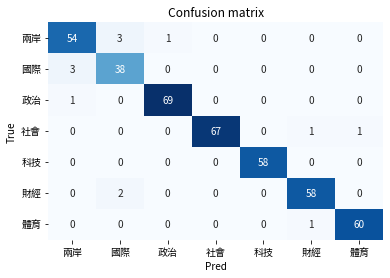

In [36]:
## Plot confusion matrix
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
ax.set(
    xlabel="Pred",
    ylabel="True",
    xticklabels=classes,
    yticklabels=classes,
    title="Confusion matrix",
)
plt.yticks(rotation=0)

In [37]:
# one-hot encoding
label_binarizer = LabelBinarizer()
label_binarizer.fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
print(y_onehot_test.shape)  # (n_samples, n_classes)
y_onehot_test[0,:]

(417, 7)


array([1, 0, 0, 0, 0, 0, 0])

In [38]:
y_test.iloc[0]

'兩岸'

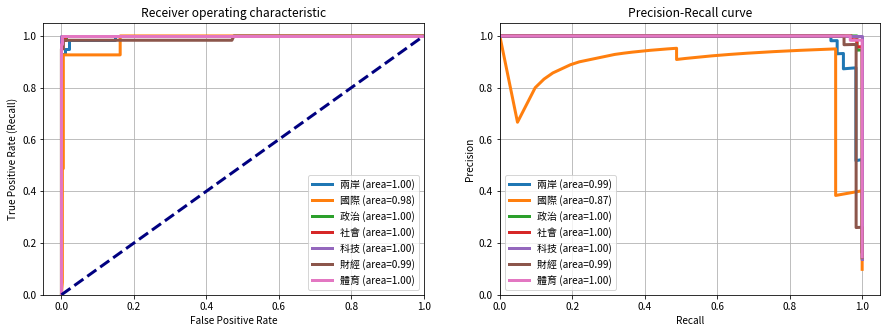

In [39]:
# plot ROC curve and precision-recall curve
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
## Plot roc
for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
    ax[0].plot(
        fpr, tpr, lw=3, label="{0} (area={1:0.2f})".format(classes[i], auc(fpr, tpr))
    )
ax[0].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
ax[0].set(
    xlim=[-0.05, 1.0],
    ylim=[0.0, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate (Recall)",
    title="Receiver operating characteristic",
)
ax[0].legend(loc="lower right")
ax[0].grid(True)

## Plot precision-recall curve
for i in range(len(classes)):
    precision, recall, thresholds = precision_recall_curve(
        y_onehot_test[:, i], y_pred_proba[:, i]
    )
    ax[1].plot(
        recall,
        precision,
        lw=3,
        label="{0} (area={1:0.2f})".format(classes[i], auc(recall, precision)),
    )
ax[1].set(
    xlim=[0.0, 1.05],
    ylim=[0.0, 1.05],
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-Recall curve",
)
ax[1].legend(loc="best")
ax[1].grid(True)

plt.show()


tfidf


In [40]:
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)
vec_train.toarray()[0,:]

array([0.        , 0.        , 0.        , 0.21543549, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.09299048, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.24590131, 0.        ,
       0.        , 0.09977729, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.06739953, 0.        , 0.     

In [41]:
clf.fit(vec_train, y_train)
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

# results
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          兩岸       0.96      0.95      0.96        58
          國際       0.90      0.93      0.92        41
          政治       0.93      1.00      0.97        70
          社會       1.00      0.97      0.99        69
          科技       1.00      1.00      1.00        58
          財經       1.00      0.97      0.98        60
          體育       1.00      0.98      0.99        61

    accuracy                           0.97       417
   macro avg       0.97      0.97      0.97       417
weighted avg       0.97      0.97      0.97       417



cv

In [42]:
clf = LogisticRegression()
vec_train = CountVectorizer(max_features=1000).fit_transform(X_train)

scores = cross_validate(clf, vec_train, y_train, cv=5, scoring=("f1_macro", "recall_macro", "precision_macro"), return_estimator=True)
pprint(scores)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

{'estimator': [LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression()],
 'fit_time': array([0.14436126, 0.21791244, 0.20960784, 0.18896317, 0.20080447]),
 'score_time': array([0.        , 0.01003909, 0.00804615, 0.00804186, 0.0016315 ]),
 'test_f1_macro': array([0.98074341, 0.97370863, 0.98921064, 0.99500108, 0.95845768]),
 'test_precision_macro': array([0.98210395, 0.9750463 , 0.98941799, 0.995671  , 0.96024948]),
 'test_recall_macro': array([0.98018899, 0.97370487, 0.98940345, 0.99450549, 0.95774915])}


In [54]:
y_pred = cross_val_predict(clf, vec_train, y_train, cv=5)
print(classification_report(y_train, y_pred))

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

          兩岸       0.98      0.94      0.96       142
          國際       0.95      0.99      0.97       159
          政治       0.98      0.96      0.97       130
          社會       0.98      0.99      0.99       130
          科技       1.00      1.00      1.00       142
          財經       0.98      0.97      0.97       130
          體育       0.99      1.00      1.00       139

    accuracy                           0.98       972
   macro avg       0.98      0.98      0.98       972
weighted avg       0.98      0.98      0.98       972



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

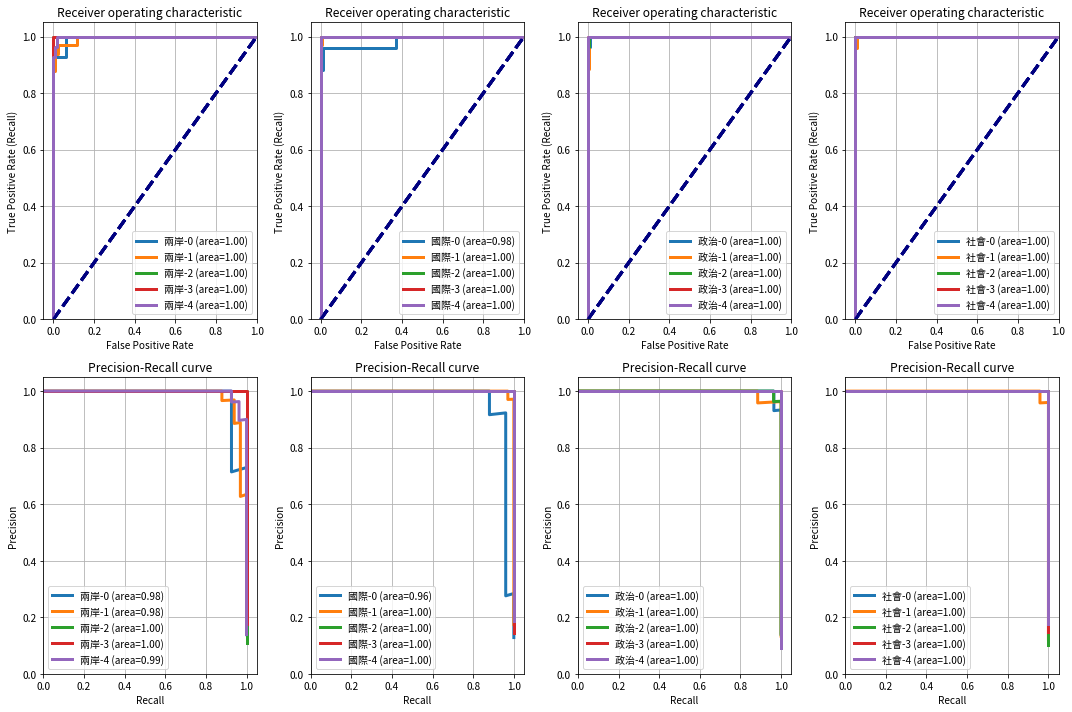

In [55]:

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))
kf = KFold(n_splits=5)
classes = scores['estimator'][0].classes_

for k, (train, test) in enumerate(kf.split(vec_train, y_train)):
    clf.fit(vec_train[train, :], y_train.iloc[train])
    y_pred_proba = clf.predict_proba(vec_train[test, :])
    y_onehot_test = label_binarizer.transform(y_train.iloc[test])

    # Plot ROC curve
    for i in range(min(len(classes), 4)):
        fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
        ax[0, i].plot(
            fpr,
            tpr,
            lw=3,
            label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(fpr, tpr)),
        )
        ax[0, i].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
        ax[0, i].set(
            xlim=[-0.05, 1.0],
            ylim=[0.0, 1.05],
            xlabel="False Positive Rate",
            ylabel="True Positive Rate (Recall)",
            title="Receiver operating characteristic",
        )
        ax[0, i].legend(loc="best")
        ax[0, i].grid(True)

    # Plot Precision-Recall curve
    for i in range(min(len(classes), 4)):
        precision, recall, thresholds = precision_recall_curve(
            y_onehot_test[:, i], y_pred_proba[:, i]
        )
        ax[1, i].plot(
            recall,
            precision,
            lw=3,
            label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(recall, precision)),
        )
        ax[1, i].set(
            xlim=[0.0, 1.05],
            ylim=[0.0, 1.05],
            xlabel="Recall",
            ylabel="Precision",
            title="Precision-Recall curve",
        )
        ax[1, i].legend(loc="best")
        ax[1, i].grid(True)

# Remove unused subplots
if len(classes) < 4:
    for i in range(len(classes), 4):
        fig.delaxes(ax[0, i])
        fig.delaxes(ax[1, i])

plt.tight_layout()
plt.show()


比較不同模型

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

def train_cv(vectorizer, clf, X, y):
    vec_X = vectorizer.fit_transform(X).toarray()
    cv_results = cross_validate(clf, vec_X, y, cv=5, return_estimator=True)
    y_pred = cross_val_predict(clf, vec_X, y, cv=5)
    y_pred_proba = cross_val_predict(clf, vec_X, y, cv=5, method="predict_proba")
    
    cls_report = classification_report(y, y_pred, output_dict=True)
    print(classification_report(y, y_pred))
    
    classes = cv_results['estimator'][0].classes_
    
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(
        xlabel="Pred",
        ylabel="True",
        xticklabels=classes,
        yticklabels=classes,
        title="Confusion matrix",
    )
    plt.yticks(rotation=0)

    fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))

    kf = KFold(n_splits=5)
    
    for k, (train, test) in enumerate(kf.split(vec_X, y)):
        clf.fit(vec_X[train, :], y.iloc[train])
        y_pred = clf.predict(vec_X[test, :])    
        y_test = y.iloc[test]
        y_pred_proba = clf.predict_proba(vec_X[test, :])
        y_onehot_test = label_binarizer.transform(y_test)        
        
        for i in range(min(len(classes), 4)):
            fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
            ax[0, i].plot(
                fpr,
                tpr,
                lw=3,
                label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(fpr, tpr)),
            )
            ax[0, i].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
            ax[0, i].set(
                xlim=[-0.05, 1.0],
                ylim=[0.0, 1.05],
                xlabel="False Positive Rate",
                ylabel="True Positive Rate (Recall)",
                title="Receiver operating characteristic",
            )
            ax[0, i].legend(loc="best")
            ax[0, i].grid(True)

        for i in range(min(len(classes), 4)):
            precision, recall, thresholds = precision_recall_curve(
                y_onehot_test[:, i], y_pred_proba[:, i]
            )
            ax[1, i].plot(
                recall,
                precision,
                lw=3,
                label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(recall, precision)),
            )
            ax[1, i].set(
                xlim=[0.0, 1.05],
                ylim=[0.0, 1.05],
                xlabel="Recall",
                ylabel="Precision",
                title="Precision-Recall curve",
            )
            ax[1, i].legend(loc="best")
            ax[1, i].grid(True)

    if len(classes) < 4:
        for i in range(len(classes), 4):
            fig.delaxes(ax[0, i])
            fig.delaxes(ax[1, i])

    plt.tight_layout()
    plt.show()

    clf.fit(vec_X, y)
    return cls_report


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

              precision    recall  f1-score   support

          兩岸       0.98      0.94      0.96       142
          國際       0.95      0.99      0.97       159
          政治       0.98      0.96      0.97       130
          社會       0.98      0.99      0.99       130
          科技       1.00      1.00      1.00       142
          財經       0.98      0.97      0.97       130
          體育       0.99      1.00      1.00       139

    accuracy                           0.98       972
   macro avg       0.98      0.98      0.98       972
weighted avg       0.98      0.98      0.98       972



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

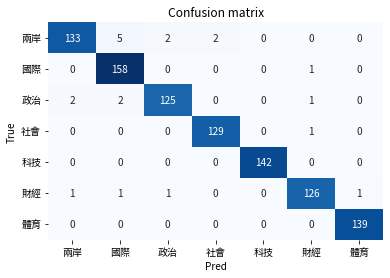

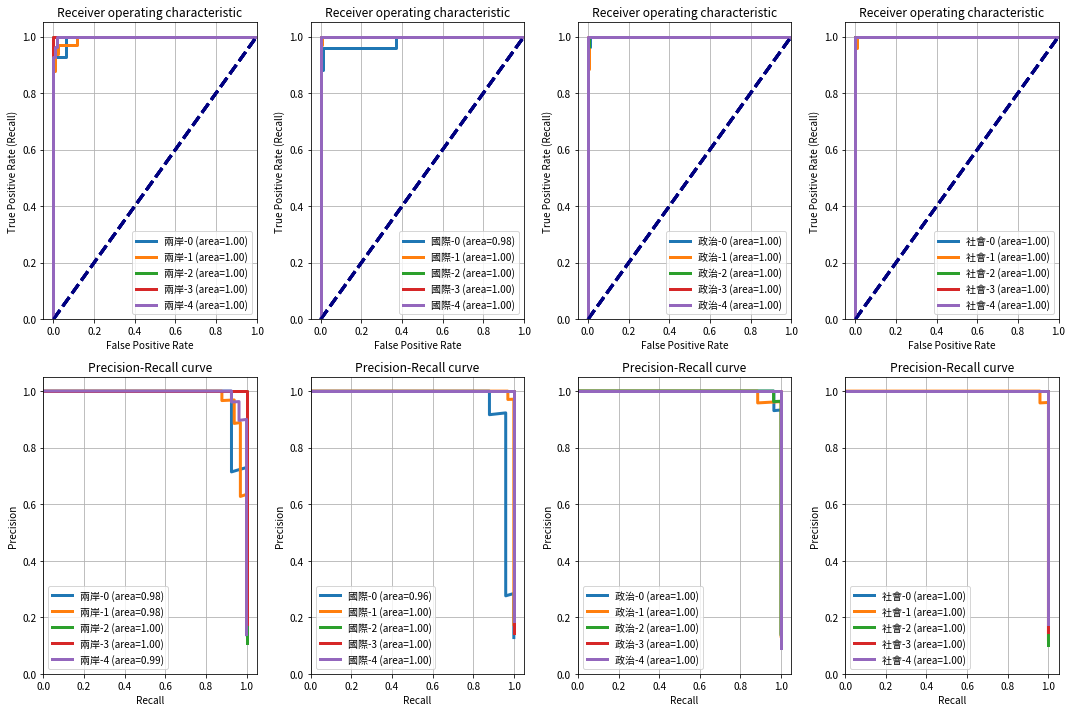

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
vectorizer = CountVectorizer(max_features=1000)
clf = LogisticRegression()
result = train_cv(vectorizer, clf, X_train, y_train)

now training: clf_logistic


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

              precision    recall  f1-score   support

          兩岸       0.98      0.94      0.96       142
          國際       0.95      0.99      0.97       159
          政治       0.98      0.96      0.97       130
          社會       0.98      0.99      0.99       130
          科技       1.00      1.00      1.00       142
          財經       0.98      0.97      0.97       130
          體育       0.99      1.00      1.00       139

    accuracy                           0.98       972
   macro avg       0.98      0.98      0.98       972
weighted avg       0.98      0.98      0.98       972



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

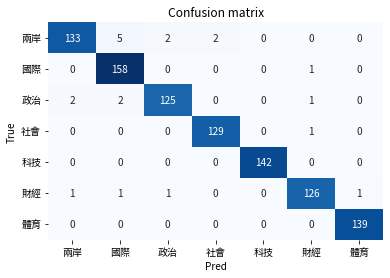

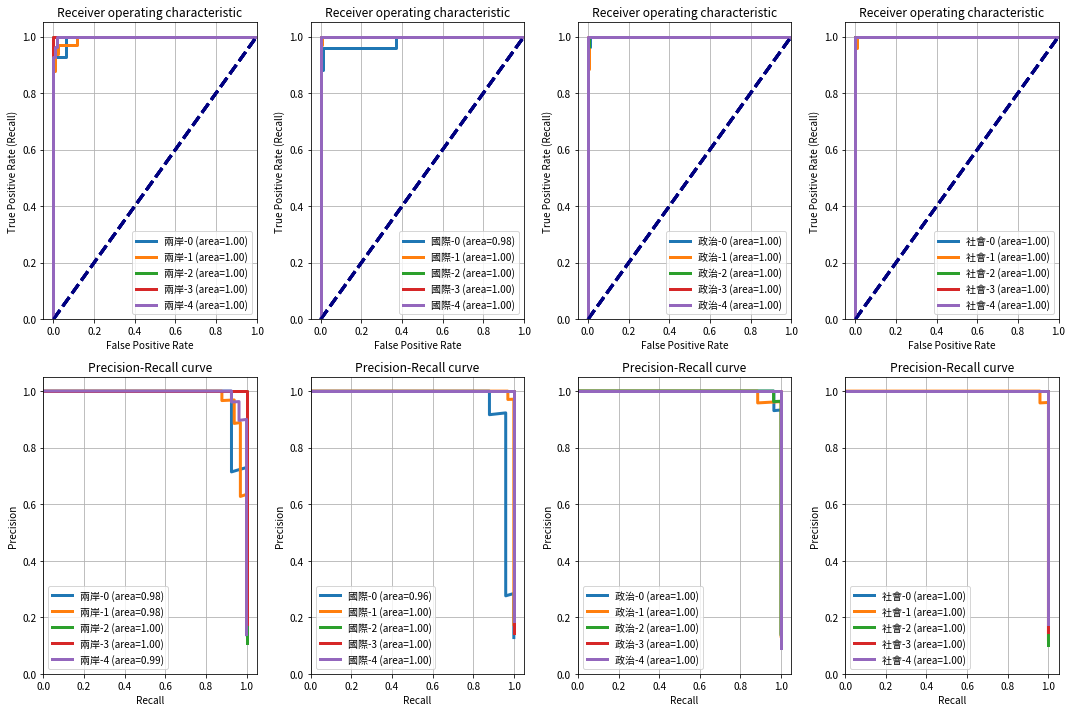

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


now training: clf_dtree
              precision    recall  f1-score   support

          兩岸       0.90      0.85      0.88       142
          國際       0.94      0.99      0.97       159
          政治       0.92      0.93      0.93       130
          社會       0.96      0.93      0.95       130
          科技       0.99      1.00      0.99       142
          財經       0.95      0.88      0.92       130
          體育       0.91      0.96      0.93       139

    accuracy                           0.94       972
   macro avg       0.94      0.94      0.94       972
weighted avg       0.94      0.94      0.94       972



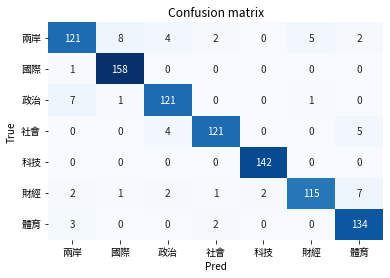

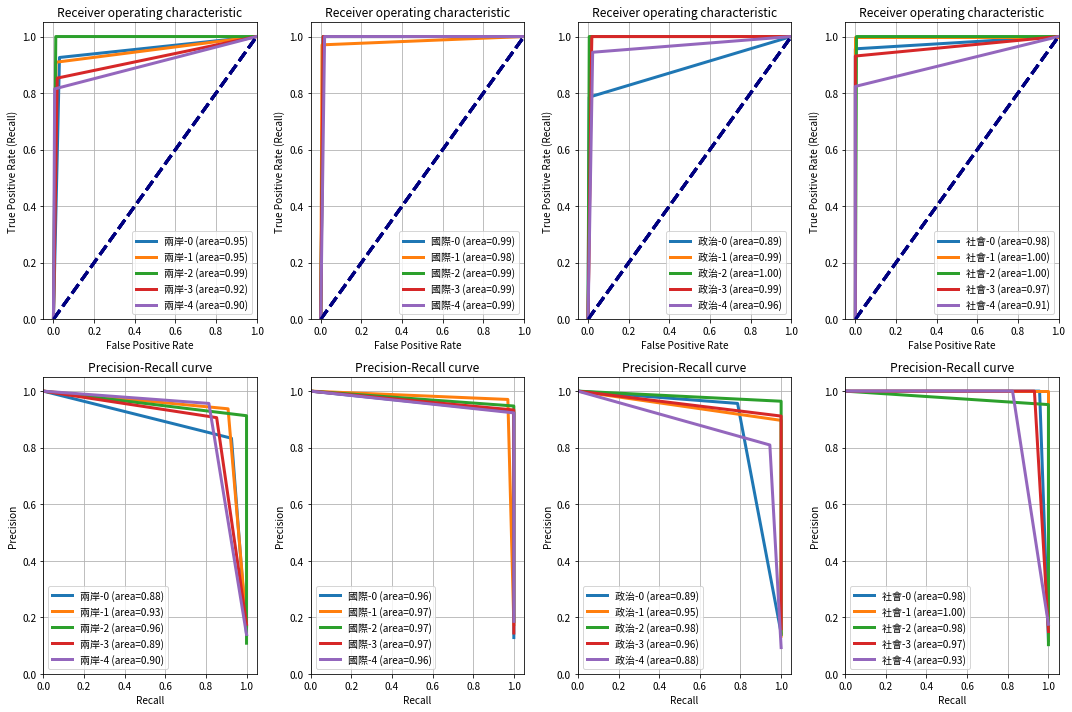

In [68]:
# 準備訓練資料
X = data["words"]
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)
# 定義模型訓練組合
model_set = dict()
model_set['clf_logistic'] = LogisticRegression()
model_set['clf_dtree'] = DecisionTreeClassifier()
# model_set['clf_rf'] = RandomForestClassifier()
# 定義 vectorizer
vectorizer = CountVectorizer(max_features=1000)
# 存結果
result_set = dict()

for k, model in model_set.items():
    print("="*100)
    print(f"now training: {k}")
    result_set[k] = train_cv(vectorizer, model, X_train, y_train)
    print("="*100)


In [69]:
max = 0
best_model_name = ""
best_model_metric = "f1-score"

## choose max f1-score model from result_set
for k, v in result_set.items():
    if v['macro avg'][best_model_metric] > max:
        max = v['macro avg'][best_model_metric]
        best_model_name = k
print(f"best model: {best_model_name}")
pprint(result_set[best_model_name])

best model: clf_logistic
{'accuracy': 0.9794238683127572,
 'macro avg': {'f1-score': 0.9794327090646481,
               'precision': 0.9800921512453409,
               'recall': 0.9790581904586688,
               'support': 972},
 'weighted avg': {'f1-score': 0.9793523093104176,
                  'precision': 0.9795856745629381,
                  'recall': 0.9794238683127572,
                  'support': 972},
 '兩岸': {'f1-score': 0.9568345323741008,
        'precision': 0.9779411764705882,
        'recall': 0.9366197183098591,
        'support': 142},
 '國際': {'f1-score': 0.9723076923076922,
        'precision': 0.9518072289156626,
        'recall': 0.9937106918238994,
        'support': 159},
 '政治': {'f1-score': 0.9689922480620154,
        'precision': 0.9765625,
        'recall': 0.9615384615384616,
        'support': 130},
 '社會': {'f1-score': 0.9885057471264368,
        'precision': 0.9847328244274809,
        'recall': 0.9923076923076923,
        'support': 130},
 '科技': {'f1-score':

In [70]:
y_pred = model_set['clf_logistic'].predict(vectorizer.transform(X_test))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          兩岸       0.93      0.93      0.93        58
          國際       0.88      0.93      0.90        41
          政治       0.99      0.99      0.99        70
          社會       1.00      0.97      0.99        69
          科技       1.00      1.00      1.00        58
          財經       0.97      0.97      0.97        60
          體育       0.98      0.98      0.98        61

    accuracy                           0.97       417
   macro avg       0.96      0.97      0.97       417
weighted avg       0.97      0.97      0.97       417



In [71]:
model_set['clf_logistic'].predict(vectorizer.transform(["市場 將 迎來 許多 大企業 的 財報 美國 股市 主要指數 今天 早盤 小幅震盪"]))

array(['財經'], dtype=object)

In [72]:
model_set[best_model_name]

LogisticRegression()

In [73]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 選出某個類別的前10大影響力字詞
    log_odds = logistic_reg_model.coef_.T
    coef_df = pd.DataFrame(
        log_odds, 
        columns=logistic_reg_model.classes_, index=feature_names
    )
    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        word = select_words.index
        count = select_words[label]
        category_colors = np.where(
            select_words[label] >= 0, "darkseagreen", "rosybrown"
        )  # 設定顏色

        fig, ax = plt.subplots(figsize=(8, top_n*0.8))  # 設定畫布
        plt.rcParams["axes.unicode_minus"] = False

        ax.barh(word, count, color=category_colors)
        ax.invert_yaxis()
        ax.set_title(
            "Coeff increase/decrease odds ratio of 「" + label + "」 label the most",
            loc="left",
            size=16,
        )
        ax.set_ylabel("word", size=14)
        ax.set_xlabel("Word Frequency", size=14)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


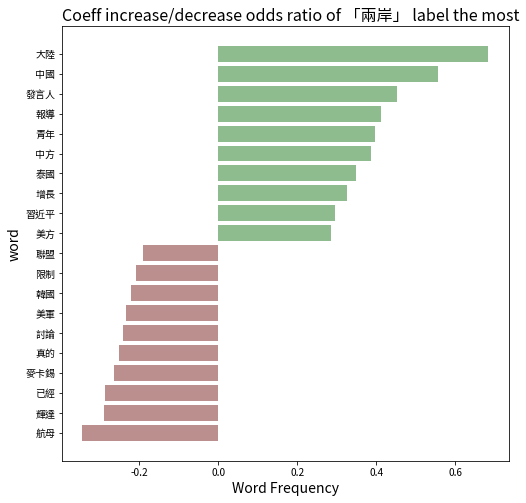

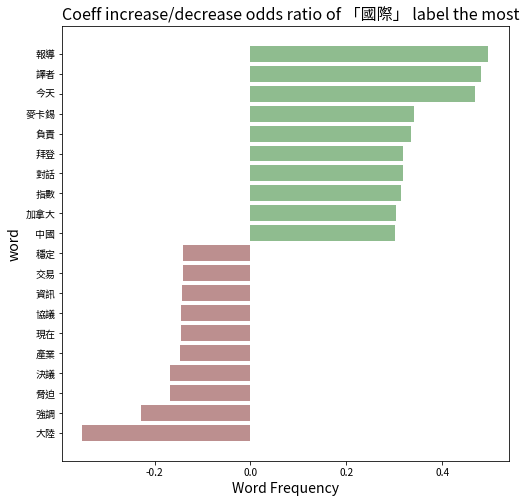

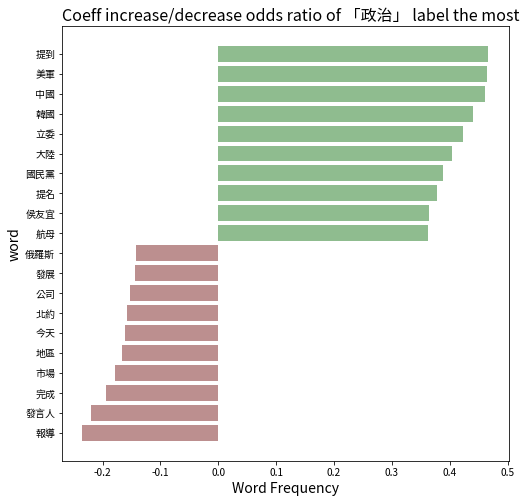

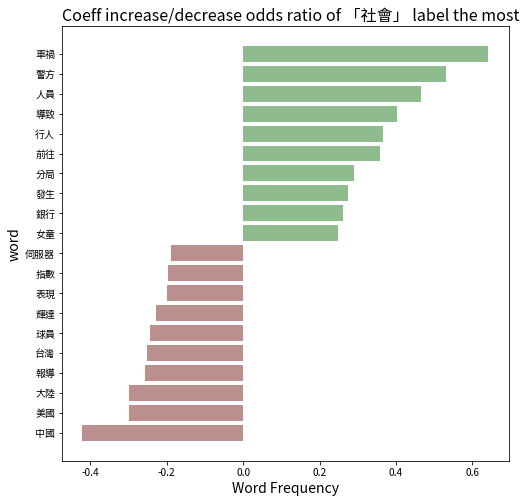

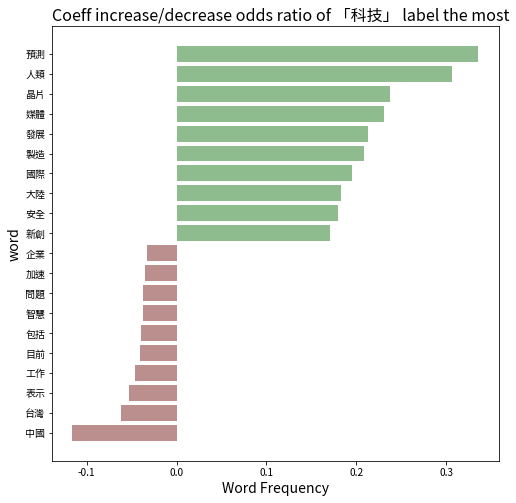

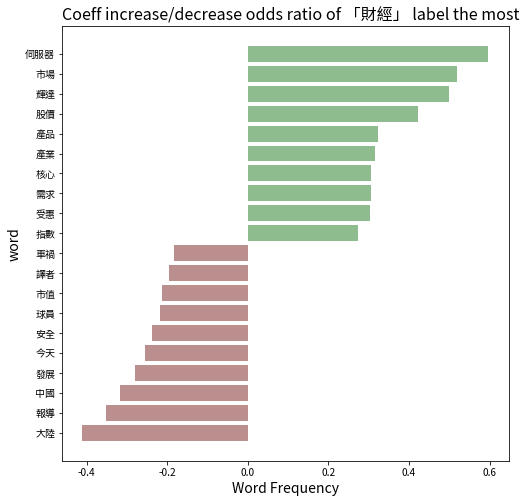

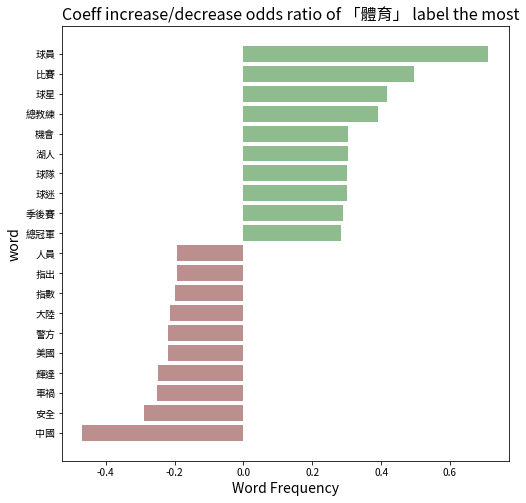

In [74]:
plot_coef(logistic_reg_model=model_set[best_model_name], feature_names=vectorizer.get_feature_names(), top_n=10)

預測新聞類別

In [81]:
# 定義模型訓練組合
## 不做 cross validation, 用 test data 來評估模型的版本
## pipeline: 資料處理 vectorizer + 分類器
def train(vectorizer, clf, X_train, y_train, X_test, y_test):

    ## train classifier
    vec_train = vectorizer.fit_transform(X_train).toarray()
    vec_test = vectorizer.transform(X_test).toarray()
    clf.fit(vec_train, y_train)
    

    ## test classifier
    y_pred = clf.predict(vec_test)
    y_pred_proba = clf.predict_proba(vec_test)

    label_binarizer = LabelBinarizer()
    label_binarizer.fit(y_train)
    y_onehot_test = label_binarizer.transform(y_test)

    ## Accuracy, Precision, Recall, F1-score
    print(classification_report(y_test, y_pred))

    classes = clf.classes_
    ## Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(
        xlabel="Pred",
        ylabel="True",
        xticklabels=classes,
        yticklabels=classes,
        title="Confusion matrix",
    )
    plt.yticks(rotation=0)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    ## Plot roc
    for i in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
        ax[0].plot(
            fpr,
            tpr,
            lw=3,
            label="{0} (area={1:0.2f})".format(classes[i], auc(fpr, tpr)),
        )
    ax[0].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
    ax[0].set(
        xlim=[-0.05, 1.0],
        ylim=[0.0, 1.05],
        xlabel="False Positive Rate",
        ylabel="True Positive Rate (Recall)",
        title="Receiver operating characteristic",
    )
    ax[0].legend(loc="lower right")
    ax[0].grid(True)

    ## Plot precision-recall curve
    for i in range(len(classes)):
        precision, recall, thresholds = precision_recall_curve(
            y_onehot_test[:, i], y_pred_proba[:, i]
        )
        ax[1].plot(
            recall,
            precision,
            lw=3,
            label="{0} (area={1:0.2f})".format(classes[i], auc(recall, precision)),
        )
    ax[1].set(
        xlim=[0.0, 1.05],
        ylim=[0.0, 1.05],
        xlabel="Recall",
        ylabel="Precision",
        title="Precision-Recall curve",
    )
    ax[1].legend(loc="best")
    ax[1].grid(True)

    plt.show()

    # return the model object
    return classification_report(y_test, y_pred, output_dict=True)


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

          兩岸       0.93      0.93      0.93        58
          國際       0.88      0.93      0.90        41
          政治       0.99      0.99      0.99        70
          社會       1.00      0.97      0.99        69
          科技       1.00      1.00      1.00        58
          財經       0.97      0.97      0.97        60
          體育       0.98      0.98      0.98        61

    accuracy                           0.97       417
   macro avg       0.96      0.97      0.97       417
weighted avg       0.97      0.97      0.97       417



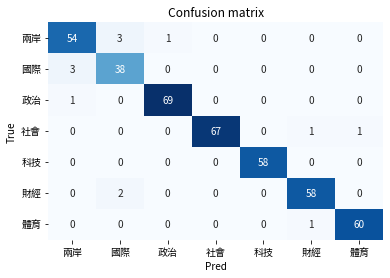

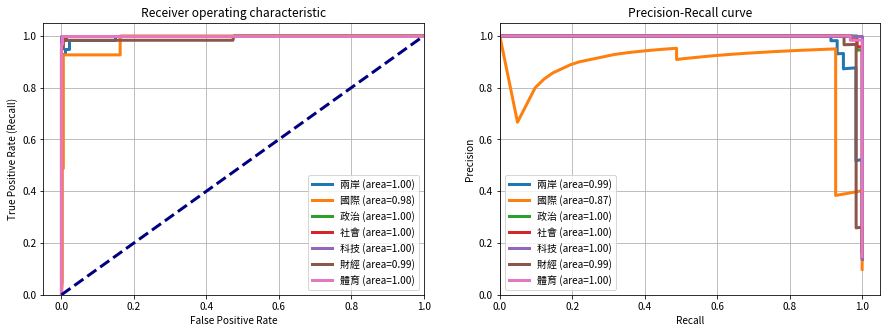

{'兩岸': {'precision': 0.9310344827586207,
  'recall': 0.9310344827586207,
  'f1-score': 0.9310344827586207,
  'support': 58},
 '國際': {'precision': 0.8837209302325582,
  'recall': 0.926829268292683,
  'f1-score': 0.9047619047619047,
  'support': 41},
 '政治': {'precision': 0.9857142857142858,
  'recall': 0.9857142857142858,
  'f1-score': 0.9857142857142858,
  'support': 70},
 '社會': {'precision': 1.0,
  'recall': 0.9710144927536232,
  'f1-score': 0.9852941176470589,
  'support': 69},
 '科技': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 58},
 '財經': {'precision': 0.9666666666666667,
  'recall': 0.9666666666666667,
  'f1-score': 0.9666666666666667,
  'support': 60},
 '體育': {'precision': 0.9836065573770492,
  'recall': 0.9836065573770492,
  'f1-score': 0.9836065573770492,
  'support': 61},
 'accuracy': 0.9688249400479616,
 'macro avg': {'precision': 0.9643918461070259,
  'recall': 0.9664093933661327,
  'f1-score': 0.9652968592750837,
  'support': 417},
 'weighted avg': {'precisi

In [82]:
data = udn
X = data["words"]
y = data["artCatagory"]
# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)
vectorizer = CountVectorizer(max_features=1000)
clf = LogisticRegression()
train(vectorizer, clf, X_train, y_train, X_test, y_test)